# Autoencoders

### Callback


In [1]:
from dataclasses import dataclass
from datetime import datetime

@dataclass
class MetricsValue:
    value: float
    value_name: str

@dataclass
class MetricsDto:
    name: str
    timestamp: datetime
    step: int
    step_type: str
    phase: str
    values: list[MetricsValue]

In [2]:
import tensorflow as tf
import json
import paho.mqtt.client as mqtt
import csv
import os
from datetime import datetime
from dataclasses import asdict

folder = "AccuracyFiles/"
os.makedirs(folder, exist_ok=True)

filename = folder + "/Accuracy_" + datetime.now().isoformat() + ".csv"

class AccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, train_name, epoch_offset=0):
        self.offset = epoch_offset
        self.name = train_name
        try:
            self.mqtt_client = mqtt.Client()
            broker = '169.254.51.0'
            port = 1883
            self.mqtt_client.connect(broker, port)
            self.mqtt_client.loop_start()

        except Exception as e:
            print(f"Error conectando con el broker: {e}")
            self.mqtt = None

    def on_epoch_end(self, epoch, logs=None,  ):
        now = datetime.now().isoformat()
        train_dto = MetricsDto(
            name= self.name,
            timestamp=now,
            step=epoch + self.offset,
            step_type="epoch",
            phase="train",
            values=[
                MetricsValue(value=float(logs.get("loss", 0.0)), value_name="loss")
            ]
        )
        val_dto = MetricsDto(
        name= self.name,
        timestamp=now,
        step=epoch + self.offset,
        step_type="epoch",
        phase="val",
        values=[
            MetricsValue(value=float(logs.get("val_loss", 0.0)), value_name="loss")
        ]
        )
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(train_dto)), qos=1)
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(val_dto)), qos=1)


    def save_data(self, data):
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([datetime.now().isoformat(), data["epoch"], data["accuracy"]])




I0000 00:00:1777561658.090186    3970 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777561663.227675    3970 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777561671.317300    3970 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 1. ORIGINAL (propuesto por Vanessa)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


# Cargar MNIST
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar (784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


# Definir Autoencoder

encoding_dim = 32  # compresión fuerte

input_img = tf.keras.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento

autoencoder.fit(
    X_train,
    X_train,   # <- importante: entrada = salida
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("MNIST/AE")]
)

# Reconstrucción

decoded_imgs = autoencoder.predict(X_test[:10])

# Visualización

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

### 2. Dataset = CIFAR-10

#### 2.1. 2 layers

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e2])
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e1])
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/SKIP/Conv2")]
)


/tmp/ipykernel_4346/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 211s 535ms/step - loss: 0.0454 - val_loss: 0.0261
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 209s 534ms/step - loss: 0.0175 - val_loss: 0.0173
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 209s 534ms/step - loss: 0.0144 - val_loss: 0.0116
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 208s 533ms/step - loss: 0.0124 - val_loss: 0.0110
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 208s 533ms/step - loss: 0.0115 - val_loss: 0.0116


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/BASIC/Conv2")]
)


/tmp/ipykernel_4346/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 170s 431ms/step - loss: 0.0813 - val_loss: 0.0561
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 168s 430ms/step - loss: 0.0512 - val_loss: 0.0475
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 168s 429ms/step - loss: 0.0435 - val_loss: 0.0420
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 430ms/step - loss: 0.0402 - val_loss: 0.0387
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 201s 429ms/step - loss: 0.0378 - val_loss: 0.0365


#### 2.2. 2 layers, menos kernels

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(bn)

# Decoder

d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e2])
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e1])
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/SKIP/Conv2S")]
)


/tmp/ipykernel_3970/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 95s 238ms/step - loss: 0.0571 - val_loss: 0.0262
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 93s 237ms/step - loss: 0.0231 - val_loss: 0.0244
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - loss: 0.0197 - val_loss: 0.0174
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 238ms/step - loss: 0.0163 - val_loss: 0.0168
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 95s 243ms/step - loss: 0.0150 - val_loss: 0.0176


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/BASIC/Conv2S")]
)


/tmp/ipykernel_4346/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 194ms/step - loss: 0.0910 - val_loss: 0.0622
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - loss: 0.0563 - val_loss: 0.0549
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 193ms/step - loss: 0.0503 - val_loss: 0.0483
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 193ms/step - loss: 0.0473 - val_loss: 0.0460
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - loss: 0.0454 - val_loss: 0.0438


#### 2.3. 3 layers

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e3])
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e2])
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Concatenate()([d3, e1])
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/SKIP/Conv3")]
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

/tmp/ipykernel_3970/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Error conectando con el broker: timed out
Epoch 1/5
 16/391 ━━━━━━━━━━━━━━━━━━━━ 4:15 681ms/step - loss: 0.2145

KeyboardInterrupt: 

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[AccuracyCallback("CIFAR/AE/BASIC/Conv3")]
)


/tmp/ipykernel_3970/4270769900.py:19: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 220s 555ms/step - loss: 0.1184 - val_loss: 0.0927
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 216s 553ms/step - loss: 0.0745 - val_loss: 0.0681
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 555ms/step - loss: 0.0658 - val_loss: 0.0646
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 220s 562ms/step - loss: 0.0588 - val_loss: 0.0580
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 555ms/step - loss: 0.0548 - val_loss: 0.0539


#### 2.4. VISUALIZAR

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


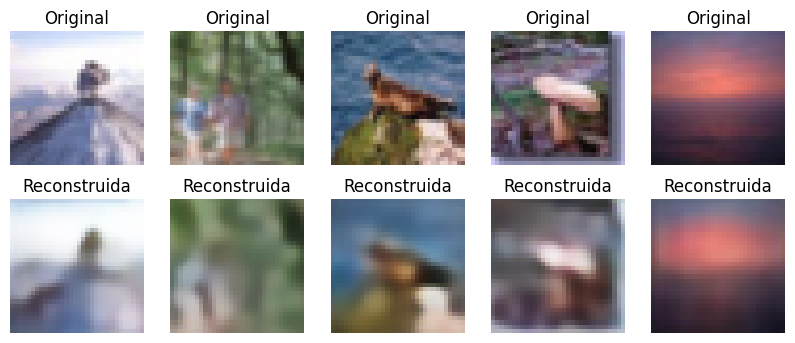

In [11]:
# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

# Visualización
n = 5
plt.figure(figsize=(10,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

### 3. Pruebas con Dataset RealWaste

#### 3.1. No convolucional

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

encoding_dim = 32

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = tf.keras.Input(shape=(64,64,3))

# Encoder
x = layers.Flatten()(input_img)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(768, activation='relu')(x)
encoded = layers.Dense(encoding_dim, activation='relu')(x)

# Decoder
x = layers.Dense(768, activation='relu')(encoded)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(64*64*3, activation='sigmoid')(x)
decoded = layers.Reshape((64,64,3))(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=3,
    validation_data=val_dataset,
    callbacks=[AccuracyCallback("AE/RealWaste/Whole")]
)

# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:10])

    n = 10
    plt.figure(figsize=(20, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()

#### 3.2. Convolucional

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = layers.Input(shape=(128,128,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(128,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e2])
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e1])
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[AccuracyCallback("AE/RealWaste/Conv")]
)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = layers.Input(shape=(128,128,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e3])
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e2])
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Concatenate()([d3, e1])
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[AccuracyCallback("AE/RealWaste/Conv")]
)


In [ ]:
# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:5])

    n = 5
    plt.figure(figsize=(10, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()